# 1. Exploratory Data Analysis
**Dataset**: AIO26 Hepatic Patient Outcome Prediction  
**Task**: Multi-class classification - predict `Status` ∈ {C, D, CL}  
**Data paths**:
- Raw  : `../data/raw/`
- Plots: `../eda_figures/`

## 1.1 Imports & Setup

In [39]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

# ── Aesthetic config - light research theme ──────────────────────────────────
# Surface / ink / grid from a validated light palette
BG, FG, GRID = '#fcfcfb', '#1a1a1a', '#d9d8d1'
MUTED, MEDIAN, EDGE = '#52514e', '#0b0b0b', '#c3c2b7'
# Categorical accents: blue / green / red (CVD-safe)
ACCENT1, ACCENT2, ACCENT3 = '#2a78d6', '#008300', '#e34948'
# Survival status → semantic + CVD-safe: alive=blue, transplant=amber, death=red
PALETTE_STATUS = {'C': '#2a78d6', 'CL': '#eda100', 'D': '#e34948'}
STATUS_ORDER   = ['C', 'CL', 'D']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': EDGE, 'axes.labelcolor': FG,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': FG, 'grid.color': GRID,
    'grid.linestyle': '--', 'grid.alpha': 0.7,
    'font.family': 'DejaVu Sans', 'font.size': 11
})

os.makedirs('../eda_figures', exist_ok=True)
print('Setup complete ✅')

Setup complete ✅


## 1.2 Load Raw Data

In [40]:
train = pd.read_csv('../data/raw/aio26_train.csv')
test  = pd.read_csv('../data/raw/aio26_test.csv')
sub   = pd.read_csv('../data/raw/aio26_sample-submission.csv')

# Derived feature for readability
train['Patient_Age_Years'] = train['Patient_Age_Days'] / 365.25
test['Patient_Age_Years']  = test['Patient_Age_Days']  / 365.25

print(f'Train : {train.shape}  |  Test : {test.shape}')
train.head(3)

Train : (12000, 21)  |  Test : (10000, 20)


,id,Followup_Days,Treatment_Assignment,Patient_Age_Days,Patient_Sex,Ascites_Indicator,Liver_Enlargement,Spider_Angioma,Edema_Status,Bilirubin_Level,...,Albumin_Level,Copper_Level,Alkaline_Phosphatase,AST_Level,Triglyceride_Level,Platelet_Count,Prothrombin_Time,Clinical_Stage,Status,Patient_Age_Years
0,7523,1416,Treatment_A,26612,Female,Absent,Absent,Absent,Controlled,0.50,...,3.517,15.1,726.3,83.97,NaN,258.2,9.87,2.0,C,72.859685
1,10266,3182,Treatment_A,18647,Female,Absent,Absent,Absent,NaN,0.55,...,4.087,30.0,669.6,58.56,65.6,272.0,10.55,3.0,C,51.052704
2,9705,1372,NaN,23408,Female,NaN,NaN,NaN,NaN,0.82,...,3.789,NaN,NaN,NaN,NaN,388.8,9.94,3.0,C,64.087611


## 1.3. Dataset Overview

In [41]:
# ── Schema ────────────────────────────────────────────────────────────────────
print('=== DATA TYPES ===')
print(train.dtypes)

print('\n=== NUMERICAL DESCRIBE ===')
display(train.describe().T)

=== DATA TYPES ===
id                        int64
Followup_Days             int64
Treatment_Assignment     object
Patient_Age_Days          int64
Patient_Sex              object
Ascites_Indicator        object
Liver_Enlargement        object
Spider_Angioma           object
Edema_Status             object
Bilirubin_Level         float64
Cholesterol_Level       float64
Albumin_Level           float64
Copper_Level            float64
Alkaline_Phosphatase    float64
AST_Level               float64
Triglyceride_Level      float64
Platelet_Count          float64
Prothrombin_Time        float64
Clinical_Stage          float64
Status                   object
Patient_Age_Years       float64
dtype: object

=== NUMERICAL DESCRIBE ===


,count,mean,std,min,25%,50%,75%,max
id,12000.0,7529.663167,4324.923037,1.000000,3809.750000,7536.500000,11285.500000,14999.000000
Followup_Days,12000.0,1978.274167,1380.381451,22.000000,1091.000000,1785.500000,2637.000000,26256.000000
Patient_Age_Days,12000.0,19311.575417,3942.174761,1129.000000,16516.250000,19592.500000,22367.750000,189456.000000
Bilirubin_Level,12000.0,1.810381,2.605157,0.260000,0.650000,0.890000,1.810000,28.380000
Cholesterol_Level,5342.0,329.261793,183.345394,30.300000,242.500000,280.550000,360.200000,1821.400000
Albumin_Level,12000.0,3.524495,0.373024,1.818000,3.284000,3.570000,3.777000,4.680000
Copper_Level,6744.0,74.768639,73.226694,3.000000,31.575000,52.400000,85.300000,672.600000
Alkaline_Phosphatase,6821.0,1643.119806,1812.447164,8.100000,721.500000,1076.400000,1672.300000,19052.800000
AST_Level,6818.0,106.879814,51.249639,2.920000,70.560000,97.605000,132.872500,602.290000
Triglyceride_Level,5305.0,111.514496,52.600434,5.700000,79.300000,99.100000,133.500000,607.600000


In [42]:
# ── Target distribution ───────────────────────────────────────────────────────
counts = train['Status'].value_counts()
print('=== TARGET DISTRIBUTION ===')
for k, v in counts.items():
    print(f'  {k:5s}  {v:6,d}  ({v/len(train)*100:.1f}%)')

=== TARGET DISTRIBUTION ===
  C       8,151  (67.9%)
  D       3,532  (29.4%)
  CL        317  (2.6%)


## 1.4. Missing Values

In [43]:
miss_train = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss_test  = (test.isnull().sum()  / len(test)  * 100).sort_values(ascending=False)

miss_df = pd.DataFrame({'Train %': miss_train, 'Test %': miss_test}).dropna(how='all')
miss_df = miss_df[miss_df['Train %'] > 0]
print('=== MISSING VALUES (%) ===')
display(miss_df.style.background_gradient(cmap='Reds', axis=None))

=== MISSING VALUES (%) ===


,Train %,Test %
AST_Level,43.183333,43.960000
Alkaline_Phosphatase,43.158333,43.960000
Ascites_Indicator,43.083333,43.910000
Cholesterol_Level,55.483333,56.240000
Copper_Level,43.800000,44.540000
Edema_Status,92.100000,92.510000
Liver_Enlargement,43.100000,43.920000
Platelet_Count,3.708333,3.850000
Prothrombin_Time,0.116667,0.110000
Spider_Angioma,43.125000,43.940000


## 1.5. Figure 1 - Overview Dashboard

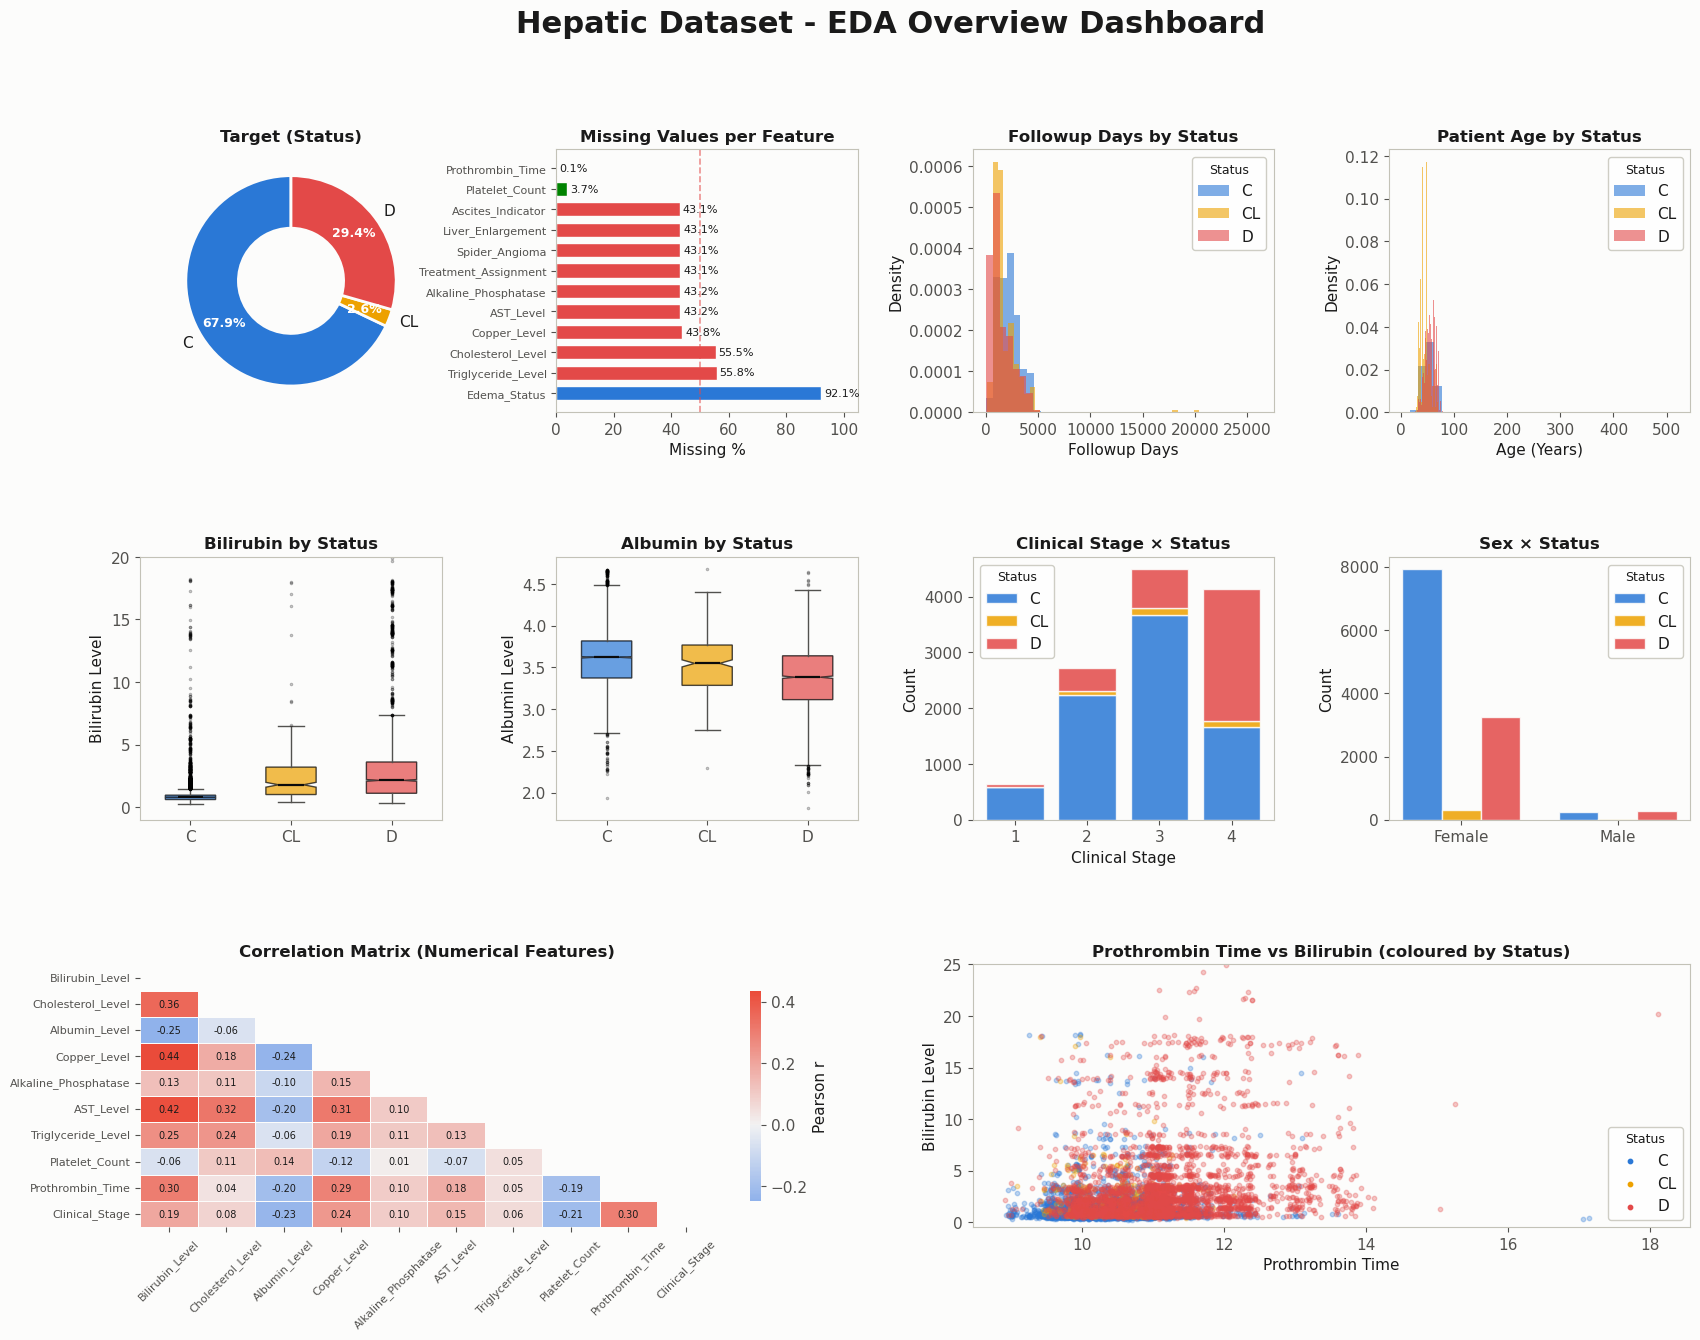

Figure 1 saved


In [44]:
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('Hepatic Dataset - EDA Overview Dashboard', fontsize=22,
             fontweight='bold', color=FG, y=0.98)
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

# ── 1. Donut: target ─────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
counts_plot = train['Status'].value_counts().reindex(STATUS_ORDER)
colors = [PALETTE_STATUS[s] for s in STATUS_ORDER]
wedges, texts, autotexts = ax0.pie(
    counts_plot, labels=STATUS_ORDER, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
for t  in texts:     t.set_color(FG)
ax0.add_artist(plt.Circle((0, 0), 0.5, fc=BG))
ax0.set_title('Target (Status)', color=FG, fontsize=12, fontweight='bold')

# ── 2. Missing values bar ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
miss_nz = miss_train[miss_train > 0]
bar_colors = [ACCENT1 if v > 80 else (ACCENT3 if v > 40 else ACCENT2) for v in miss_nz.values]
bars = ax1.barh(miss_nz.index, miss_nz.values, color=bar_colors, height=0.7, edgecolor=BG)
ax1.set_xlabel('Missing %', color=FG); ax1.set_xlim(0, 105)
ax1.set_title('Missing Values per Feature', color=FG, fontsize=12, fontweight='bold')
ax1.axvline(50, color=ACCENT3, linestyle='--', alpha=0.6, lw=1.2)
for bar, val in zip(bars, miss_nz.values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color=FG)
ax1.tick_params(axis='y', labelsize=8)

# ── 3. Followup Days by Status ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
for status, color in PALETTE_STATUS.items():
    ax2.hist(train[train['Status'] == status]['Followup_Days'],
             bins=40, alpha=0.6, color=color, label=status, density=True)
ax2.set_xlabel('Followup Days'); ax2.set_ylabel('Density')
ax2.set_title('Followup Days by Status', color=FG, fontsize=12, fontweight='bold')
ax2.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=9)

# ── 4. Patient Age by Status ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
for status, color in PALETTE_STATUS.items():
    ax3.hist(train[train['Status'] == status]['Patient_Age_Years'],
             bins=35, alpha=0.6, color=color, label=status, density=True)
ax3.set_xlabel('Age (Years)'); ax3.set_ylabel('Density')
ax3.set_title('Patient Age by Status', color=FG, fontsize=12, fontweight='bold')
ax3.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=9)

# ── 5. Bilirubin boxplot ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for i, (status, color) in enumerate(PALETTE_STATUS.items()):
    data = train[train['Status'] == status]['Bilirubin_Level'].dropna()
    ax4.boxplot(data, positions=[i], widths=0.5, patch_artist=True, notch=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color=MEDIAN, lw=1.6),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='.', color=color, alpha=0.3, markersize=3))
ax4.set_xticks([0, 1, 2]); ax4.set_xticklabels(list(PALETTE_STATUS.keys()))
ax4.set_ylabel('Bilirubin Level'); ax4.set_ylim(-1, 20)
ax4.set_title('Bilirubin by Status', color=FG, fontsize=12, fontweight='bold')

# ── 6. Albumin boxplot ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for i, (status, color) in enumerate(PALETTE_STATUS.items()):
    data = train[train['Status'] == status]['Albumin_Level'].dropna()
    ax5.boxplot(data, positions=[i], widths=0.5, patch_artist=True, notch=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color=MEDIAN, lw=1.6),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='.', color=color, alpha=0.3, markersize=3))
ax5.set_xticks([0, 1, 2]); ax5.set_xticklabels(list(PALETTE_STATUS.keys()))
ax5.set_ylabel('Albumin Level')
ax5.set_title('Albumin by Status', color=FG, fontsize=12, fontweight='bold')

# ── 7. Clinical Stage × Status stacked bar ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
stage_counts = train.groupby(['Clinical_Stage', 'Status']).size().unstack(fill_value=0)
stage_counts = stage_counts[[c for c in STATUS_ORDER if c in stage_counts.columns]]
bottom = np.zeros(len(stage_counts))
for status in STATUS_ORDER:
    if status in stage_counts.columns:
        vals = stage_counts[status].values
        ax6.bar(stage_counts.index, vals, bottom=bottom,
                color=PALETTE_STATUS[status], label=status, alpha=0.85, edgecolor=BG)
        bottom += vals
ax6.set_xlabel('Clinical Stage'); ax6.set_ylabel('Count')
ax6.set_title('Clinical Stage × Status', color=FG, fontsize=12, fontweight='bold')
ax6.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=9)

# ── 8. Sex × Status grouped bar ──────────────────────────────────────────────
ax7 = fig.add_subplot(gs[1, 3])
sex_status = train.groupby(['Patient_Sex', 'Status']).size().unstack(fill_value=0)
sex_status = sex_status[[c for c in STATUS_ORDER if c in sex_status.columns]]
x = np.arange(len(sex_status)); width = 0.25
for j, status in enumerate(STATUS_ORDER):
    if status in sex_status.columns:
        ax7.bar(x + j*width, sex_status[status], width=width,
                color=PALETTE_STATUS[status], label=status, alpha=0.85, edgecolor=BG)
ax7.set_xticks(x + width); ax7.set_xticklabels(sex_status.index)
ax7.set_ylabel('Count')
ax7.set_title('Sex × Status', color=FG, fontsize=12, fontweight='bold')
ax7.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=9)

# ── 9. Correlation heatmap ────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, :2])
num_cols = ['Bilirubin_Level','Cholesterol_Level','Albumin_Level','Copper_Level',
            'Alkaline_Phosphatase','AST_Level','Triglyceride_Level',
            'Platelet_Count','Prothrombin_Time','Clinical_Stage']
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax8, cmap=sns.diverging_palette(255, 15, s=80, l=55, as_cmap=True),
            center=0, annot=True, fmt='.2f', annot_kws={'size': 7, 'color': FG},
            linewidths=0.5, linecolor=BG, cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax8.set_title('Correlation Matrix (Numerical Features)', color=FG, fontsize=12, fontweight='bold')
ax8.tick_params(axis='x', rotation=45, labelsize=8)
ax8.tick_params(axis='y', rotation=0, labelsize=8)

# ── 10. Prothrombin vs Bilirubin scatter ──────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2:])
for status, color in PALETTE_STATUS.items():
    subset = train[train['Status'] == status]
    ax9.scatter(subset['Prothrombin_Time'], subset['Bilirubin_Level'],
                c=color, alpha=0.3, s=10, label=status)
ax9.set_xlabel('Prothrombin Time'); ax9.set_ylabel('Bilirubin Level'); ax9.set_ylim(-0.5, 25)
ax9.set_title('Prothrombin Time vs Bilirubin (coloured by Status)', color=FG, fontsize=12, fontweight='bold')
leg = ax9.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=9)
for lh in leg.legend_handles: lh.set_alpha(1)

plt.savefig('../eda_figures/fig1_overview_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 1 saved')

## 1.6. Figure 2 - Violin Distributions by Status

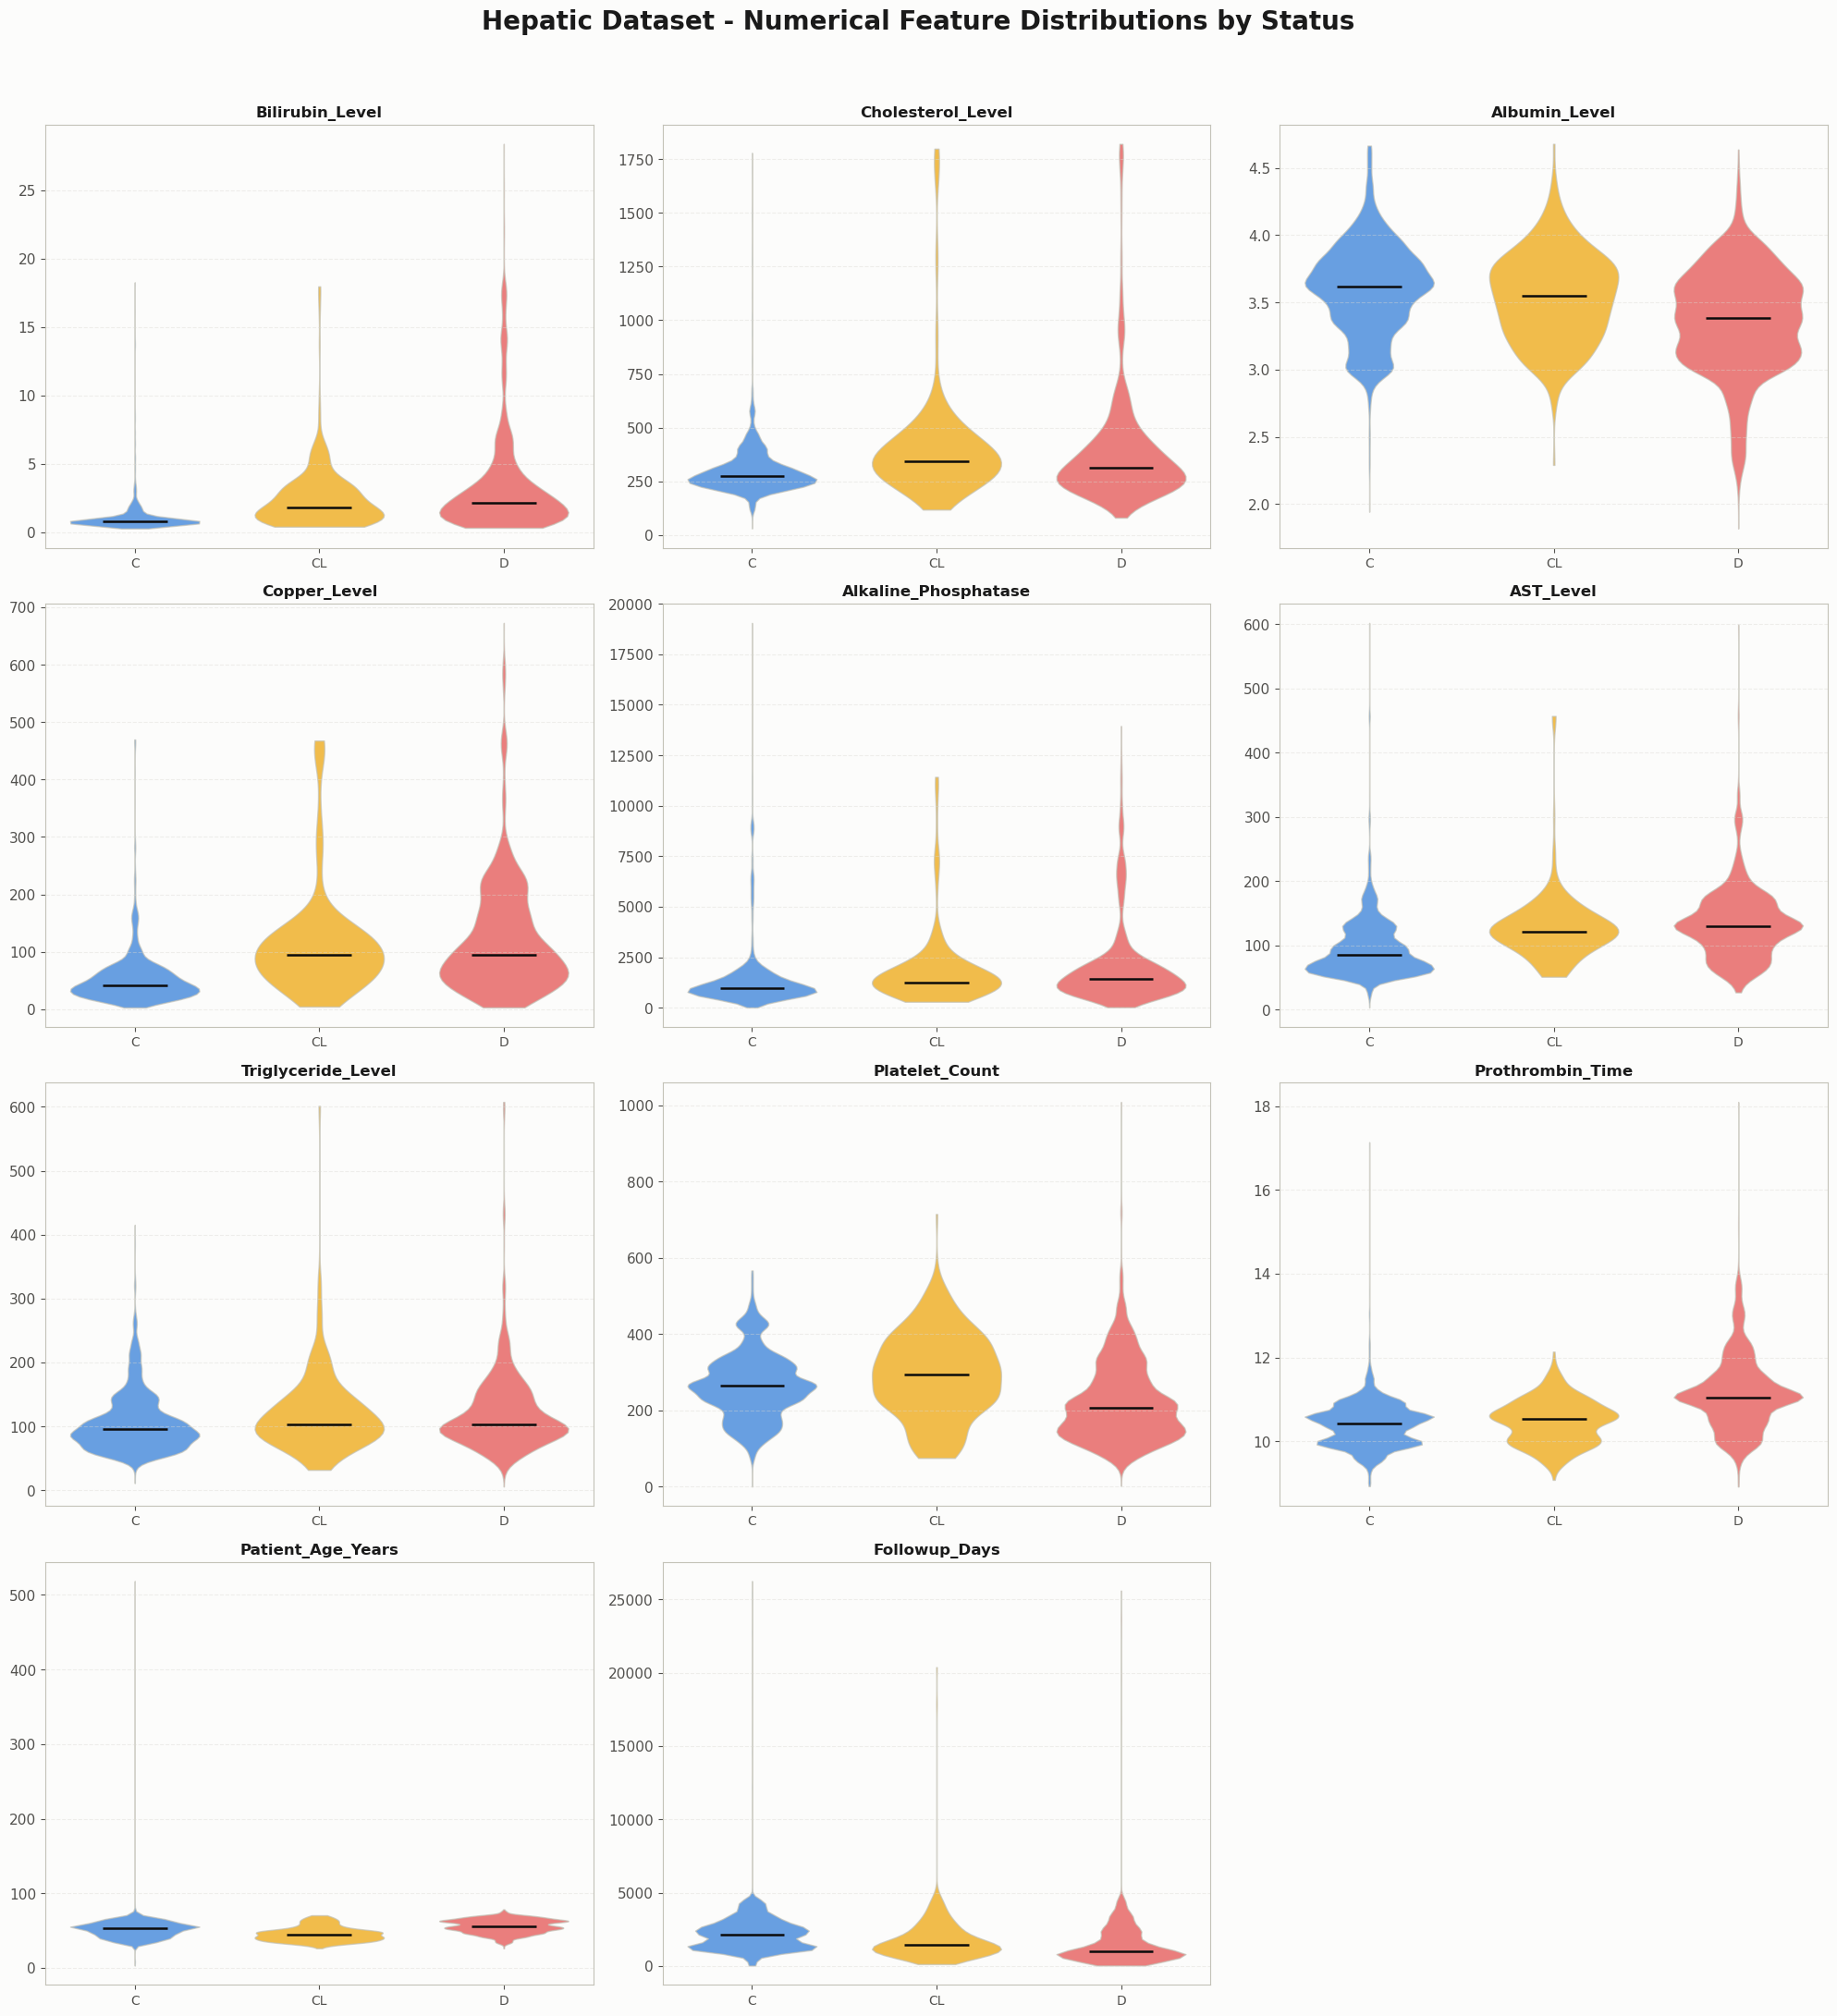

Figure 2 saved


In [45]:
num_feats = ['Bilirubin_Level','Cholesterol_Level','Albumin_Level','Copper_Level',
             'Alkaline_Phosphatase','AST_Level','Triglyceride_Level',
             'Platelet_Count','Prothrombin_Time','Patient_Age_Years','Followup_Days']

fig, axes = plt.subplots(4, 3, figsize=(20, 22), facecolor=BG)
fig.suptitle('Hepatic Dataset - Numerical Feature Distributions by Status',
             fontsize=20, fontweight='bold', color=FG, y=0.99)
axes = axes.flatten()

for idx, feat in enumerate(num_feats):
    ax = axes[idx]
    data_list = [train[train['Status']==s][feat].dropna().values for s in STATUS_ORDER]
    colors = [PALETTE_STATUS[s] for s in STATUS_ORDER]
    parts = ax.violinplot(data_list, positions=[0, 1, 2], widths=0.7,
                          showmedians=True, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color); pc.set_alpha(0.7); pc.set_edgecolor(EDGE)
    parts['cmedians'].set_color(MEDIAN); parts['cmedians'].set_linewidth(1.8)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(STATUS_ORDER, fontsize=10)
    ax.set_title(feat, color=FG, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)

axes[-1].set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../eda_figures/fig2_violin_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 2 saved')

## 1.7. Figure 3 - Categorical Features vs Status

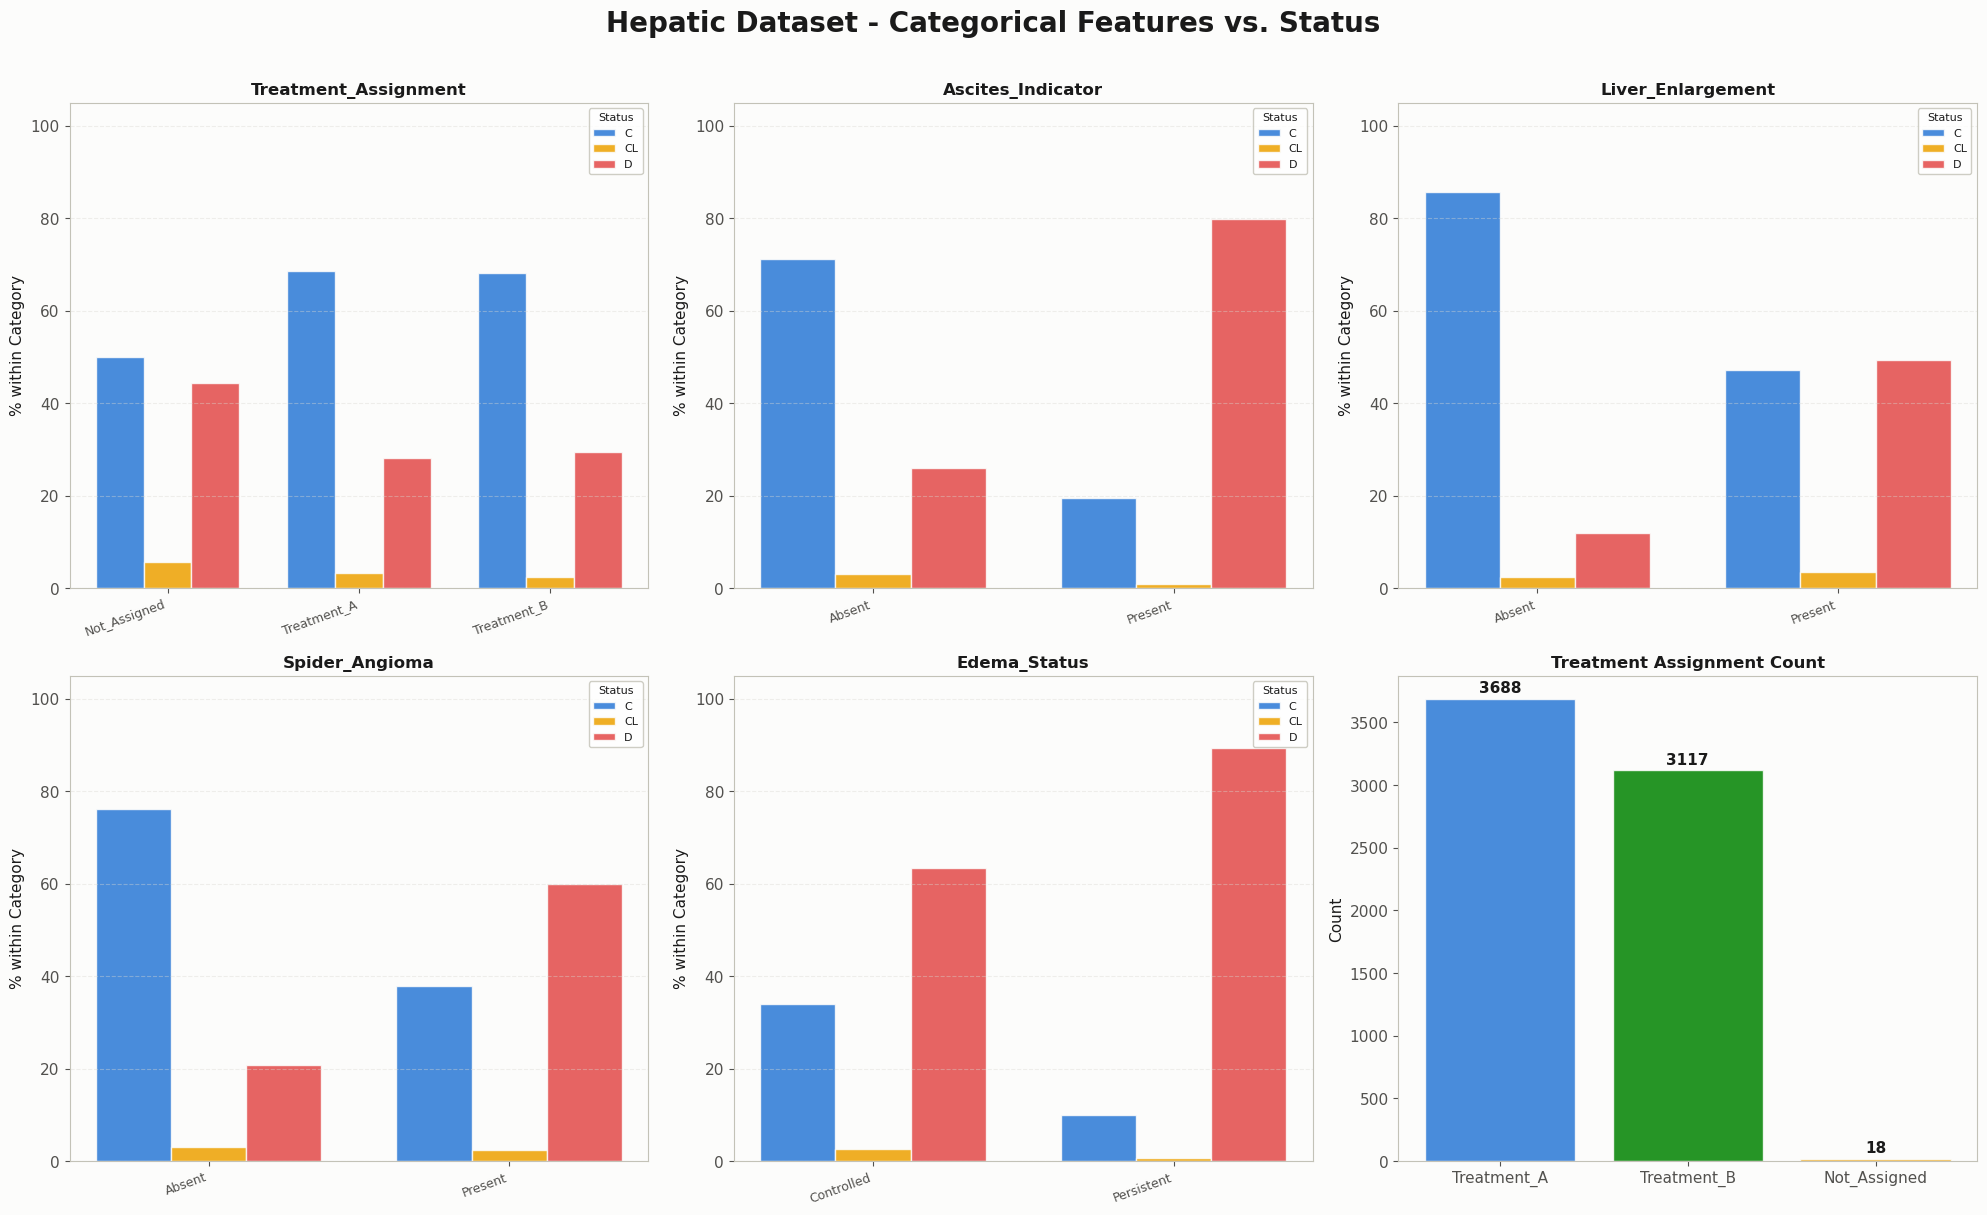

Figure 3 saved 


In [46]:
cat_feats = ['Treatment_Assignment','Ascites_Indicator','Liver_Enlargement',
             'Spider_Angioma','Edema_Status']

fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG)
fig.suptitle('Hepatic Dataset - Categorical Features vs. Status',
             fontsize=20, fontweight='bold', color=FG, y=1.01)
axes = axes.flatten()

for idx, feat in enumerate(cat_feats):
    ax = axes[idx]
    ct = train.groupby([feat, 'Status']).size().unstack(fill_value=0)
    cols = [c for c in STATUS_ORDER if c in ct.columns]
    ct = ct[cols]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    x = np.arange(len(ct_pct)); width = 0.25
    for j, status in enumerate(cols):
        ax.bar(x + j*width - width*(len(cols)-1)/2, ct_pct[status],
               width=width, color=PALETTE_STATUS[status], label=status, alpha=0.85, edgecolor=BG)
    ax.set_xticks(x); ax.set_xticklabels(ct_pct.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('% within Category'); ax.set_ylim(0, 105)
    ax.set_title(feat, color=FG, fontsize=12, fontweight='bold')
    ax.legend(title='Status', facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG, title_fontsize=8, fontsize=8)
    ax.grid(axis='y', alpha=0.4)

# Treatment count
ax = axes[5]
trt = train['Treatment_Assignment'].value_counts()
ax.bar(trt.index, trt.values, color=[ACCENT1, ACCENT2, '#eda100'][:len(trt)], edgecolor=BG, alpha=0.85)
for i, val in enumerate(trt.values):
    ax.text(i, val + 50, str(val), ha='center', fontsize=11, color=FG, fontweight='bold')
ax.set_title('Treatment Assignment Count', color=FG, fontsize=12, fontweight='bold')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../eda_figures/fig3_categorical_features.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 3 saved ')

## 1.8. Figure 4 - Outlier & Skewness Analysis

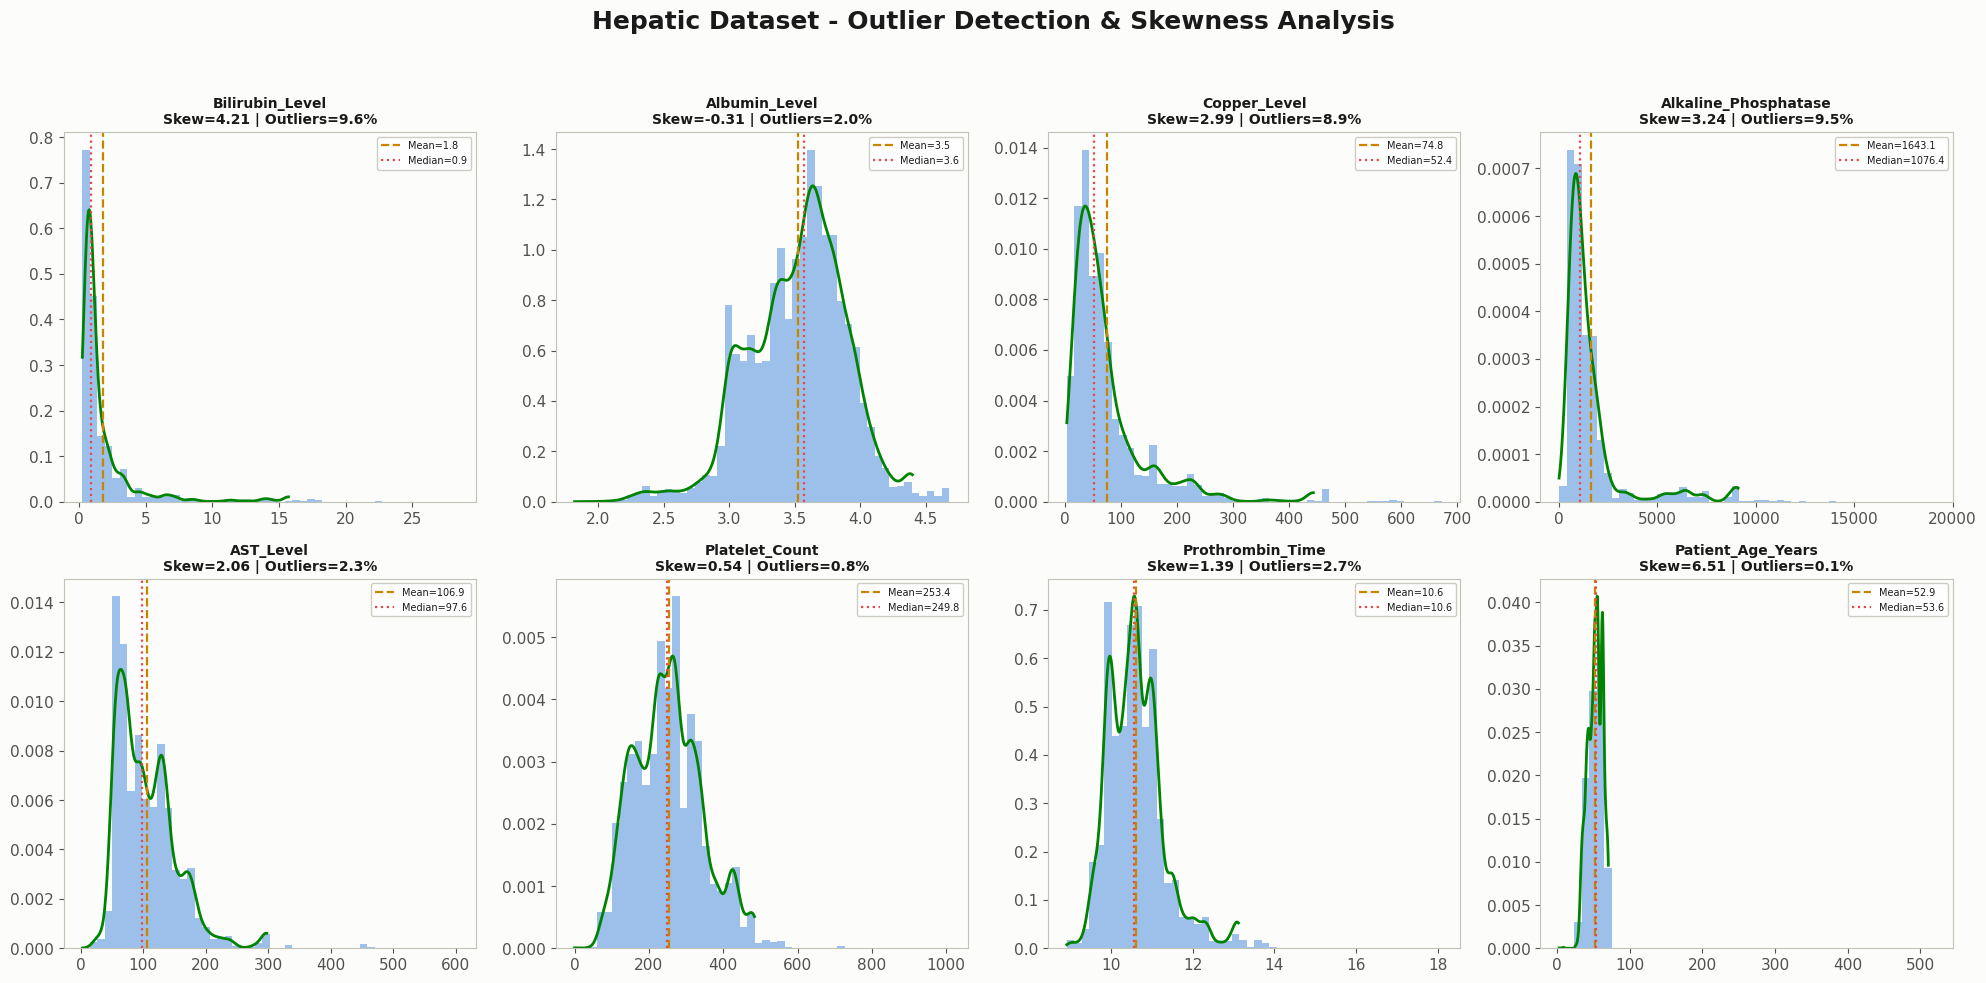

Figure 4 saved 


In [47]:
skew_feats = ['Bilirubin_Level','Albumin_Level','Copper_Level','Alkaline_Phosphatase',
              'AST_Level','Platelet_Count','Prothrombin_Time','Patient_Age_Years']

fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=BG)
fig.suptitle('Hepatic Dataset - Outlier Detection & Skewness Analysis',
             fontsize=18, fontweight='bold', color=FG)
axes = axes.flatten()

for idx, feat in enumerate(skew_feats):
    ax = axes[idx]
    data = train[feat].dropna()
    skew_val = data.skew()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outlier_pct = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum() / len(data) * 100
    ax.hist(data, bins=50, color=ACCENT1, alpha=0.45, density=True, edgecolor='none')
    kde_x = np.linspace(data.min(), data.quantile(0.99), 300)
    ax.plot(kde_x, stats.gaussian_kde(data.clip(upper=data.quantile(0.99)))(kde_x),
            color=ACCENT2, lw=2)
    ax.axvline(data.mean(),   color='#c98500', lw=1.6, linestyle='--',
               label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color=ACCENT3,   lw=1.6, linestyle=':',
               label=f'Median={data.median():.1f}')
    ax.set_title(f'{feat}\nSkew={skew_val:.2f} | Outliers={outlier_pct:.1f}%',
                 color=FG, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../eda_figures/fig4_outlier_skewness.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 4 saved ')

## 1.9. Figure 5 - Train vs. Test Distribution Drift

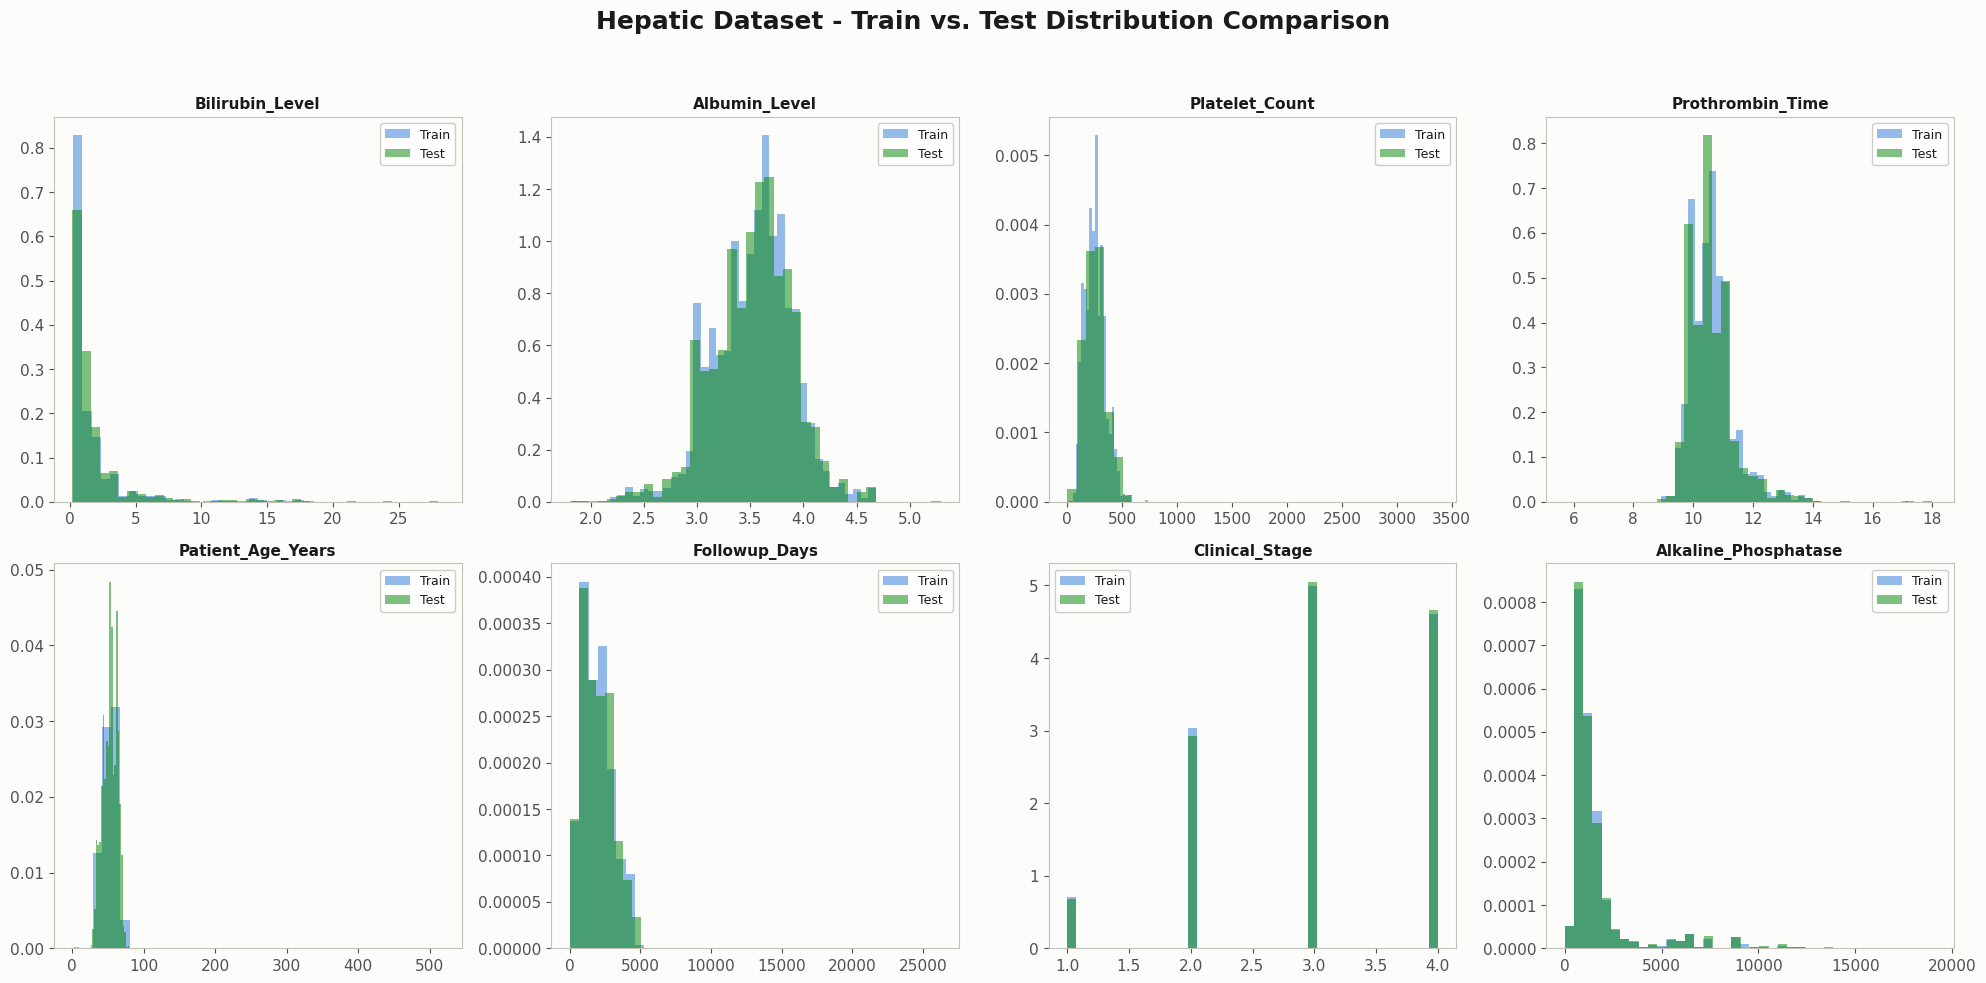

Figure 5 saved 


In [48]:
drift_feats = ['Bilirubin_Level','Albumin_Level','Platelet_Count','Prothrombin_Time',
               'Patient_Age_Years','Followup_Days','Clinical_Stage','Alkaline_Phosphatase']

fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=BG)
fig.suptitle('Hepatic Dataset - Train vs. Test Distribution Comparison',
             fontsize=18, fontweight='bold', color=FG)
axes = axes.flatten()

for idx, feat in enumerate(drift_feats):
    ax = axes[idx]
    ax.hist(train[feat].dropna(), bins=40, color=ACCENT1, alpha=0.5, density=True,
            label='Train', edgecolor='none')
    ax.hist(test[feat].dropna(),  bins=40, color=ACCENT2, alpha=0.5, density=True,
            label='Test',  edgecolor='none')
    ax.set_title(feat, color=FG, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, facecolor='#ffffff', edgecolor=EDGE, labelcolor=FG)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../eda_figures/fig5_train_test_drift.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 5 saved ')

## 1.10. Statistical Summary Table

In [49]:
num_cols = ['Bilirubin_Level','Cholesterol_Level','Albumin_Level','Copper_Level',
            'Alkaline_Phosphatase','AST_Level','Triglyceride_Level',
            'Platelet_Count','Prothrombin_Time','Patient_Age_Years','Followup_Days']

rows = []
for col in num_cols:
    d = train[col].dropna()
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    out_pct = ((d < q1 - 1.5*iqr) | (d > q3 + 1.5*iqr)).sum() / len(d) * 100
    rows.append({
        'Feature': col, 'Count': int(d.count()),
        'Missing%': round((1 - d.count()/len(train))*100, 1),
        'Mean': round(d.mean(), 2), 'Median': round(d.median(), 2),
        'Std': round(d.std(), 2), 'Skew': round(d.skew(), 2),
        'Kurt': round(d.kurtosis(), 2), 'Outlier%': round(out_pct, 1)
    })

df_stat = pd.DataFrame(rows).set_index('Feature')
display(df_stat.style.background_gradient(subset=['Skew','Outlier%'], cmap='YlOrRd'))

,Count,Missing%,Mean,Median,Std,Skew,Kurt,Outlier%
Feature,,,,,,,,
Bilirubin_Level,12000,0.000000,1.810000,0.890000,2.610000,4.210000,21.230000,9.600000
Cholesterol_Level,5342,55.500000,329.260000,280.550000,183.350000,4.590000,28.380000,6.300000
Albumin_Level,12000,0.000000,3.520000,3.570000,0.370000,-0.310000,0.580000,2.000000
Copper_Level,6744,43.800000,74.770000,52.400000,73.230000,2.990000,12.570000,8.900000
Alkaline_Phosphatase,6821,43.200000,1643.120000,1076.400000,1812.450000,3.240000,11.480000,9.500000
AST_Level,6818,43.200000,106.880000,97.600000,51.250000,2.060000,9.370000,2.300000
Triglyceride_Level,5305,55.800000,111.510000,99.100000,52.600000,2.640000,14.540000,4.300000
Platelet_Count,11555,3.700000,253.400000,249.800000,93.260000,0.540000,0.660000,0.800000
Prothrombin_Time,11986,0.100000,10.630000,10.570000,0.720000,1.390000,4.670000,2.700000


## 1.11. Kruskal-Wallis Test (Status Differentiation)

In [50]:
kw_feats = ['Bilirubin_Level','Albumin_Level','Copper_Level',
            'Prothrombin_Time','Platelet_Count','Alkaline_Phosphatase',
            'AST_Level','Cholesterol_Level']

kw_rows = []
for col in kw_feats:
    groups = [train[train['Status']==s][col].dropna() for s in ['C', 'D', 'CL']]
    h, p = stats.kruskal(*groups)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    kw_rows.append({'Feature': col, 'H-Statistic': round(h, 2), 'p-value': p, 'Significance': sig})

kw_df = pd.DataFrame(kw_rows).set_index('Feature').sort_values('H-Statistic', ascending=False)
display(kw_df.style.background_gradient(subset=['H-Statistic'], cmap='plasma'))

,H-Statistic,p-value,Significance
Feature,,,
Bilirubin_Level,3229.860000,0.000000,***
Prothrombin_Time,2361.680000,0.000000,***
Copper_Level,1300.910000,0.000000,***
AST_Level,992.490000,0.000000,***
Albumin_Level,860.880000,0.000000,***
Platelet_Count,693.390000,0.000000,***
Alkaline_Phosphatase,449.730000,0.000000,***
Cholesterol_Level,174.070000,0.000000,***


---
## EDA Summary

| Finding | Detail |
|---|---|
| **Class imbalance** | CL = 2.6% - use stratified CV + weighted metrics |
| **Top predictors** | Bilirubin, Prothrombin, Copper, Albumin, Platelet |
| **Heavy missingness** | Edema 92%, Cholesterol 55%, 7 features share ~43% |
| **Right-skewed features** | Bilirubin, ALP, Copper, Cholesterol → log1p needed |
| **No train/test drift** | Safe for standard CV |
